# Support Vector Machines for Classification with `kernlab`

## Overview

Support Vector Machines (SVMs) find the maximum-margin hyperplane separating two classes. The **kernel trick** implicitly maps features into a high-dimensional space without computing the transformation explicitly, allowing SVMs to capture non-linear decision boundaries.

**Kernels:**

| Kernel | Formula | When to use |
|---|---|---|
| **Linear** | $\langle x, x'\rangle$ | High-dimensional sparse data (text, genomics); linearly separable classes |
| **RBF / Gaussian** | $\exp(-\sigma\|x-x'\|^2)$ | Most common default; handles non-linear boundaries |
| **Polynomial** | $(\langle x,x'\rangle + c)^d$ | Image or signal data with structured interactions |

**Key hyperparameters:**

| Parameter | Controls | Typical range |
|---|---|---|
| `C` | Margin width vs. misclassification penalty; larger C = harder margin | 0.01–1000; tune on log scale |
| `sigma` (RBF) | Kernel width; larger = smoother boundary | Estimated by `sigest()`; tune around this |

**When SVMs shine:** High-dimensional feature spaces (p >> n), sparse data, problems where margin maximisation aligns with the task (e.g. spectral classification, gene expression). When n is large (> 50k) and features are tabular, gradient boosting usually outperforms SVMs.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(kernlab)     # ksvm() — SVM with kernel methods
library(yardstick)
library(patchwork)

set.seed(42)

# ── Simulate: species presence with non-linear boundary ───────────────────────
n <- 400
svm_data <- tibble(
  nitrate     = rnorm(n, 3, 1.2),
  water_qual  = rnorm(n, 6, 1.5),
  distance_km = rexp(n, 0.4),
  elevation   = rnorm(n, 200, 80),
  slope_pct   = abs(rnorm(n, 10, 5)),
  # Non-linear interaction term drives presence
  log_odds    = -2 + 0.6*water_qual - 0.7*nitrate - 0.25*distance_km +
                0.4*(water_qual > 6.5 & nitrate < 3),   # interaction threshold
  present     = factor(rbinom(n, 1, plogis(log_odds)),
                       levels=c(0,1), labels=c("absent","present"))
) %>%
  # SVMs require scaled features — critical step
  mutate(across(c(nitrate, water_qual, distance_km, elevation, slope_pct), scale))

cat(sprintf("Prevalence: %.1f%% present\n", mean(svm_data$present=="present")*100))

train_idx  <- sample(n, 300)
train_data <- svm_data[train_idx, ]
test_data  <- svm_data[-train_idx, ]

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'kernlab'


The following object is masked from 'package:purrr':

    cross


The following object is masked from

Prevalence: 30.0% present


---

## Linear SVM

In [2]:
# Linear kernel: good baseline when features >> observations or data is sparse
svm_linear <- kernlab::ksvm(
  present ~ nitrate + water_qual + distance_km + elevation + slope_pct,
  data     = train_data,
  kernel   = "vanilladot",   # linear kernel
  C        = 1,              # regularisation parameter
  prob.model = TRUE          # needed for probability estimates (slower)
)
print(svm_linear)
# Number of support vectors: observations on or inside the margin
# Training error: in-sample misclassification

# Predictions
test_preds_lin <- test_data %>%
  mutate(
    pred_class   = predict(svm_linear, newdata=test_data, type="response"),
    prob_present = predict(svm_linear, newdata=test_data, type="probabilities")[,"present"]
  )

yardstick::metrics(test_preds_lin, truth=present, estimate=pred_class) %>% print()
yardstick::roc_auc(test_preds_lin, truth=present, prob_present,
                   event_level="second") %>% print()

 Setting default kernel parameters  
Support Vector Machine object of class "ksvm" 

SV type: C-svc  (classification) 
 parameter : cost C = 1 

Linear (vanilla) kernel function. 

Number of Support Vectors : 161 

Objective Function Value : -157.3503 
Training error : 0.246667 
Probability model included. 
# A tibble: 2 × 3
  .metric  .estimator .estimate
  <chr>    <chr>          <dbl>
1 accuracy binary         0.78 
2 kap      binary         0.455
# A tibble: 1 × 3
  .metric .estimator .estimate
  <chr>   <chr>          <dbl>
1 roc_auc binary         0.840


---

## RBF Kernel SVM

In [3]:
# ── Estimate sigma using sigest() ─────────────────────────────────────────────
# sigest() estimates the range of sigma values where the kernel is informative
# Use the geometric mean of the 0.1 and 0.9 quantiles as the starting point
X_train <- model.matrix(
  present ~ nitrate + water_qual + distance_km + elevation + slope_pct - 1,
  data=train_data
)
sigma_range <- kernlab::sigest(X_train, frac=0.5)
cat(sprintf("sigest sigma range: [%.4f, %.4f]\n",
            sigma_range[1], sigma_range[3]))
sigma_start <- sigma_range[2]   # median estimate

# Fit RBF SVM with estimated sigma
svm_rbf <- kernlab::ksvm(
  present ~ nitrate + water_qual + distance_km + elevation + slope_pct,
  data       = train_data,
  kernel     = "rbfdot",
  kpar       = list(sigma=sigma_start),
  C          = 1,
  prob.model = TRUE
)
print(svm_rbf)

test_preds_rbf <- test_data %>%
  mutate(
    pred_class   = predict(svm_rbf, newdata=test_data, type="response"),
    prob_present = predict(svm_rbf, newdata=test_data, type="probabilities")[,"present"]
  )

yardstick::metrics(test_preds_rbf, truth=present, estimate=pred_class) %>% print()
yardstick::roc_auc(test_preds_rbf, truth=present, prob_present,
                   event_level="second") %>% print()

sigest sigma range: [0.0503, 0.3149]
Support Vector Machine object of class "ksvm" 

SV type: C-svc  (classification) 
 parameter : cost C = 1 

Gaussian Radial Basis kernel function. 
 Hyperparameter : sigma =  0.117858624984607 

Number of Support Vectors : 178 

Objective Function Value : -151.3966 
Training error : 0.22 
Probability model included. 
# A tibble: 2 × 3
  .metric  .estimator .estimate
  <chr>    <chr>          <dbl>
1 accuracy binary         0.74 
2 kap      binary         0.324
# A tibble: 1 × 3
  .metric .estimator .estimate
  <chr>   <chr>          <dbl>
1 roc_auc binary         0.796


---

## Tuning C and Sigma via Cross-Validation

# A tibble: 12 × 3
       C  sigma cv_error
   <dbl>  <dbl>    <dbl>
 1   1   0.0503    0.26 
 2   1   0.315     0.273
 3 100   0.0503    0.273
 4  10   0.0503    0.277
 5   0.1 0.0503    0.287
 6   0.1 0.315     0.287
 7   0.1 0.118     0.287
 8   1   0.118     0.29 
 9  10   0.118     0.293
10 100   0.118     0.293
11  10   0.315     0.307
12 100   0.315     0.33 

Best: C=1.0, sigma=0.0503, CV error=0.2600


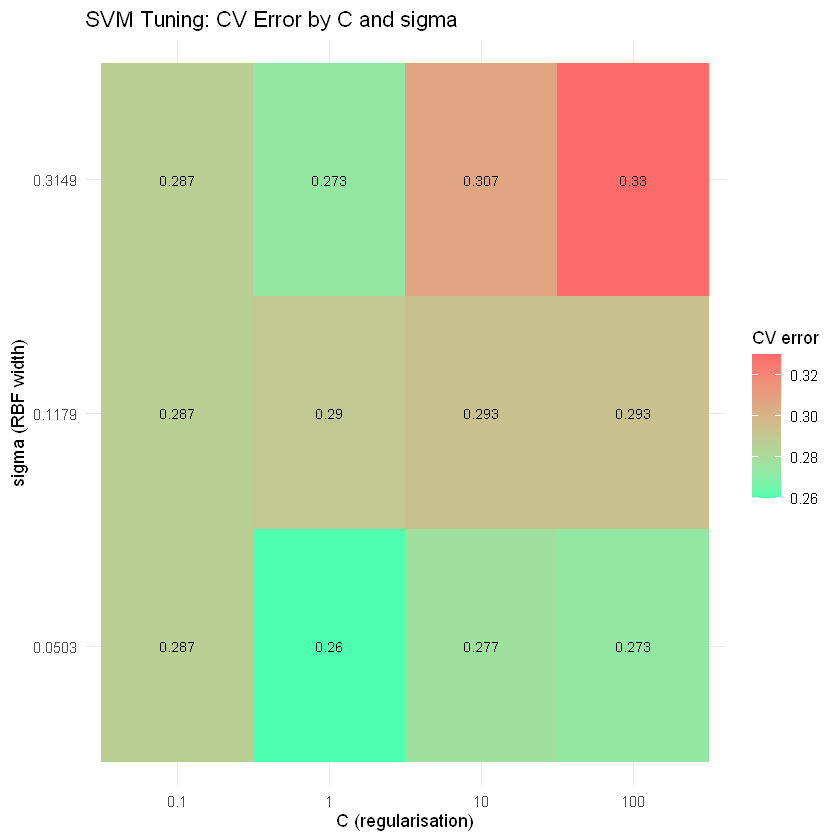

In [4]:
# Grid search over C and sigma
# C and sigma interact: tune together on a 2D grid
C_grid     <- c(0.1, 1, 10, 100)
sigma_grid <- sigma_range[c(1,2,3)]   # low, mid, high from sigest

tune_results <- expand_grid(C=C_grid, sigma=sigma_grid) %>%
  mutate(
    cv_error = map2_dbl(C, sigma, function(c_val, sig_val) {
      # ksvm with cross=5 uses 5-fold CV internally
      fit <- kernlab::ksvm(
        present ~ nitrate + water_qual + distance_km + elevation + slope_pct,
        data       = train_data,
        kernel     = "rbfdot",
        kpar       = list(sigma=sig_val),
        C          = c_val,
        cross      = 5,        # 5-fold CV
        prob.model = FALSE
      )
      cross(fit)   # returns CV error
    })
  )

print(tune_results %>% arrange(cv_error))

best_params <- tune_results %>% slice_min(cv_error)
cat(sprintf("\nBest: C=%.1f, sigma=%.4f, CV error=%.4f\n",
            best_params$C, best_params$sigma, best_params$cv_error))

# Heatmap of CV error
ggplot(tune_results,
       aes(x=factor(C), y=factor(round(sigma,4)), fill=cv_error)) +
  geom_tile() +
  geom_text(aes(label=round(cv_error,3)), size=3) +
  scale_fill_gradient(low="#4fffb0", high="#ff6b6b") +
  labs(title="SVM Tuning: CV Error by C and sigma",
       x="C (regularisation)", y="sigma (RBF width)", fill="CV error") +
  theme_minimal()

---

## Final Model and Evaluation

# A tibble: 4 × 3
  .metric     .estimator .estimate
  <chr>       <chr>          <dbl>
1 accuracy    binary         0.77 
2 sensitivity binary         0.353
3 specificity binary         0.985
4 f_meas      binary         0.511
# A tibble: 1 × 3
  .metric .estimator .estimate
  <chr>   <chr>          <dbl>
1 roc_auc binary         0.828


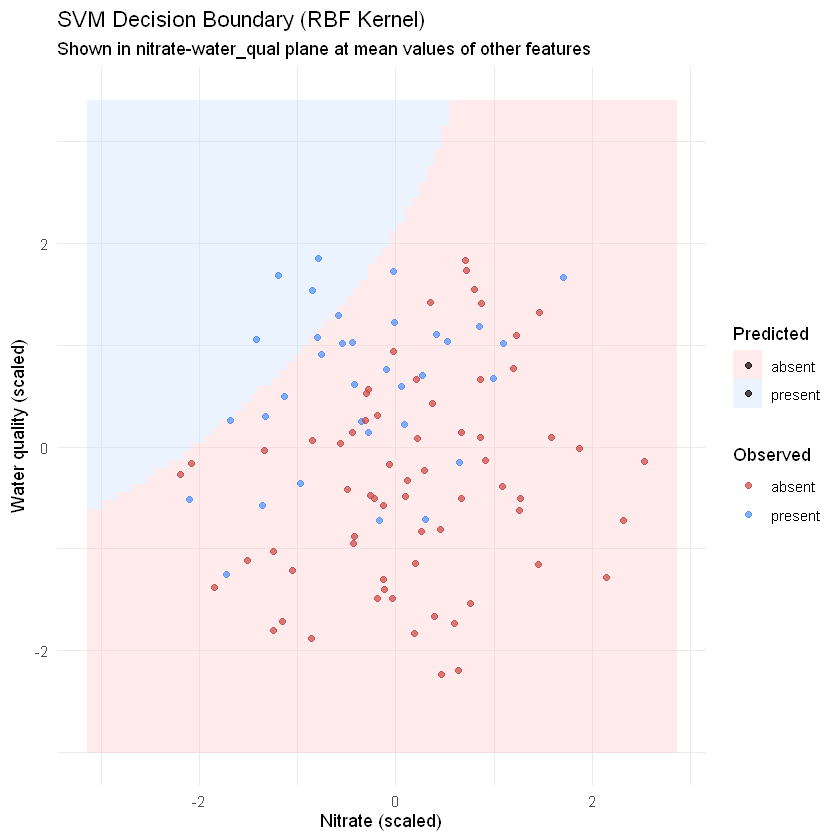

In [6]:
svm_final <- kernlab::ksvm(
  present ~ nitrate + water_qual + distance_km + elevation + slope_pct,
  data       = train_data,
  kernel     = "rbfdot",
  kpar       = list(sigma = best_params$sigma),
  C          = best_params$C,
  prob.model = TRUE
)

test_preds_final <- test_data %>%
  mutate(
    pred_class   = predict(svm_final, newdata = test_data, type = "response"),
    prob_present = predict(svm_final, newdata = test_data, type = "probabilities")[, "present"]
  )

# Full metrics
metric_set(accuracy, sensitivity, specificity, f_meas)(
  test_preds_final, truth = present, estimate = pred_class, event_level = "second"
) %>% print()
yardstick::roc_auc(test_preds_final, present, prob_present,
                   event_level = "second") %>% print()

# ── Decision boundary visualisation (2D slice) ────────────────────────────────
# Fix distance, elevation, slope at their means; vary nitrate and water_qual
grid_2d <- expand_grid(
  nitrate    = seq(min(svm_data$nitrate),    max(svm_data$nitrate),    length.out = 80),
  water_qual = seq(min(svm_data$water_qual), max(svm_data$water_qual), length.out = 80)
) %>%
  mutate(
    distance_km = 0,
    elevation   = 0,
    slope_pct   = 0
  ) %>%
  mutate(
    pred = predict(svm_final, newdata = ., type = "response")
  )

ggplot(grid_2d, aes(x = nitrate, y = water_qual, fill = pred)) +
  geom_raster(alpha = 0.4) +
  geom_point(data  = test_data,
             aes(x = nitrate, y = water_qual, color = present, fill = NULL),
             size = 1.5, alpha = 0.7) +
  scale_fill_manual(values  = c(absent = "#ffcccc", present = "#cce0ff")) +
  scale_color_manual(values = c(absent = "#cc4444", present = "#4a8fff")) +
  labs(title    = "SVM Decision Boundary (RBF Kernel)",
       subtitle = "Shown in nitrate-water_qual plane at mean values of other features",
       x = "Nitrate (scaled)", y = "Water quality (scaled)",
       fill = "Predicted", color = "Observed") +
  theme_minimal()

---

## Common Pitfalls

**1. Not scaling features before fitting an SVM**  
SVMs are sensitive to feature scale — a predictor measured in metres dominates one measured in millimetres in Euclidean distance calculations. Always standardise all features to zero mean and unit variance before fitting. The kernel computation is meaningless without scaling.

**2. Tuning C without tuning sigma**  
C and sigma interact. A large sigma makes the kernel very smooth and C has limited effect; a small sigma allows fine-grained boundaries and C is critical. Always tune both jointly on a 2D grid, not sequentially.

**3. Using `prob.model=TRUE` without understanding its cost**  
Platt scaling (`prob.model=TRUE`) fits a logistic model on the SVM scores to produce probability estimates. It adds computational cost and the probabilities can be poorly calibrated, especially near the decision boundary. If you only need class labels, set `prob.model=FALSE`.

**4. Choosing the RBF kernel by default without trying linear first**  
For high-dimensional data (p >> n), the linear kernel often matches or beats RBF with far less tuning. The linear kernel is also fully interpretable — coefficients can be extracted from the primal form. Always benchmark the linear kernel before adding kernel complexity.

**5. Using SVMs on very large datasets without a subsampling strategy**  
Training SVMs scales as O(n² ) to O(n³) with the number of training observations — practically intractable for n > 50k with the standard `ksvm` formulation. For large datasets, use gradient boosting or logistic regression. If SVMs are required, use `liquidSVM` or a stochastic approximation.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*